In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [5]:
import numpy as np

X_seq = np.load("X_seq.npy")
y_seq = np.load("y_seq.npy")

print(X_seq.shape)
print(y_seq.shape)

(912940, 30, 12)
(912940,)


In [6]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_val = X_seq[split:]

y_train = y_seq[:split]
y_val = y_seq[split:]

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

model_lstm = Sequential()

model_lstm.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(LSTM(64))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mse')

In [9]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 165s 14ms/step - loss: 227.5213 - val_loss: 54.1789
Epoch 2/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 153s 13ms/step - loss: 64.4447 - val_loss: 50.8436
Epoch 3/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 204s 14ms/step - loss: 61.4172 - val_loss: 49.6946
Epoch 4/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 157s 14ms/step - loss: 60.0074 - val_loss: 47.6485
Epoch 5/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 204s 18ms/step - loss: 59.2269 - val_loss: 47.6260


In [10]:
lstm_pred = model_lstm.predict(X_val)

5706/5706 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step


In [17]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_val, lstm_pred))

print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 6.901159283097558


In [11]:
from sklearn.metrics import mean_squared_error

rmse_lstm = np.sqrt(mean_squared_error(y_val, lstm_pred))

print("LSTM RMSE:", rmse_lstm)

LSTM RMSE: 6.901159283097558


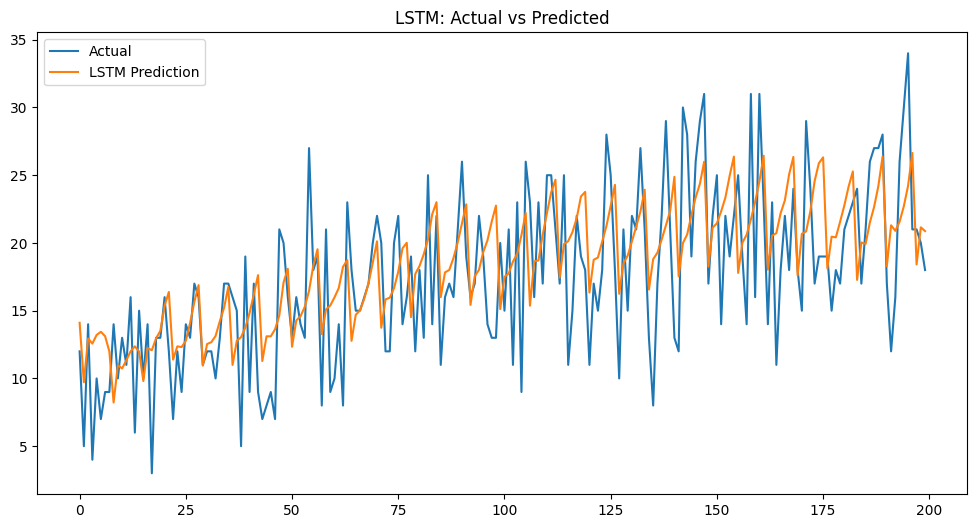

In [20]:
plt.figure(figsize=(12,6))

plt.plot(y_val[:200], label="Actual")
plt.plot(lstm_pred[:200], label="LSTM Prediction")

plt.legend()
plt.title("LSTM: Actual vs Predicted")

plt.savefig("model_comparison(LSTM).png")
plt.show()

In [13]:
model_gru = Sequential()

model_gru.add(GRU(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model_gru.add(Dense(1))

model_gru.compile(
    optimizer='adam',
    loss='mse'
)

C:\Users\daraa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 185s 16ms/step - loss: 249.4555 - val_loss: 53.8115
Epoch 2/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 187s 16ms/step - loss: 63.1865 - val_loss: 49.4035
Epoch 3/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 201s 16ms/step - loss: 60.6104 - val_loss: 48.4285
Epoch 4/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 200s 18ms/step - loss: 59.2781 - val_loss: 48.2120
Epoch 5/5
11412/11412 ━━━━━━━━━━━━━━━━━━━━ 191s 17ms/step - loss: 58.4270 - val_loss: 47.9365


In [18]:
gru_pred = model_gru.predict(X_val)

rmse_gru = np.sqrt(mean_squared_error(y_val, gru_pred))

print("GRU RMSE:", rmse_gru)

5706/5706 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step
GRU RMSE: 6.923614352306379
